

**Part 2. Lifetime exposure**
- GMT mapping 
- lifetime exposure functions

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
from math import ceil 
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

sys.path.append('..')
from gmt_mapping import * 

In [4]:
## 1) Load GMT

In [2]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrmean',
)


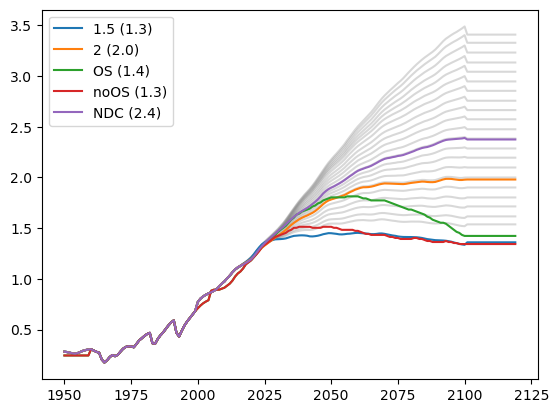

In [5]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

In [6]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
)

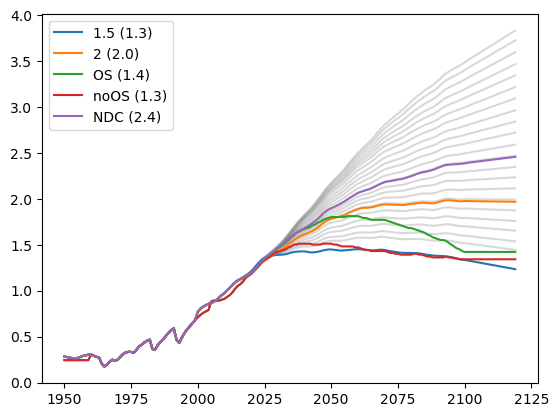

In [7]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

## 2) Load Climate data

Equivalent of load_isimip() function. Loads in data and metadata on remapping based on each trajectory

## 3) Lifetime exposure 

Per run, and aggregated across runs